<a href="https://colab.research.google.com/github/Swethamahalakshmisk/Vehicle-booking-for-college/blob/main/sign_language_predection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
429/429 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1566 - loss: 2.8085 - val_accuracy: 0.6926 - val_loss: 0.9249
Epoch 2/3
429/429 ━━━━━━━━━━━━━━━━━━━━ 40s 58ms/step - accuracy: 0.7034 - loss: 0.8487 - val_accuracy: 0.7896 - val_loss: 0.5961
Epoch 3/3
429/429 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.8661 - loss: 0.3957 - val_accuracy: 0.8535 - val_loss: 0.4015
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8536 - loss: 0.3874
Test accuracy: 0.85


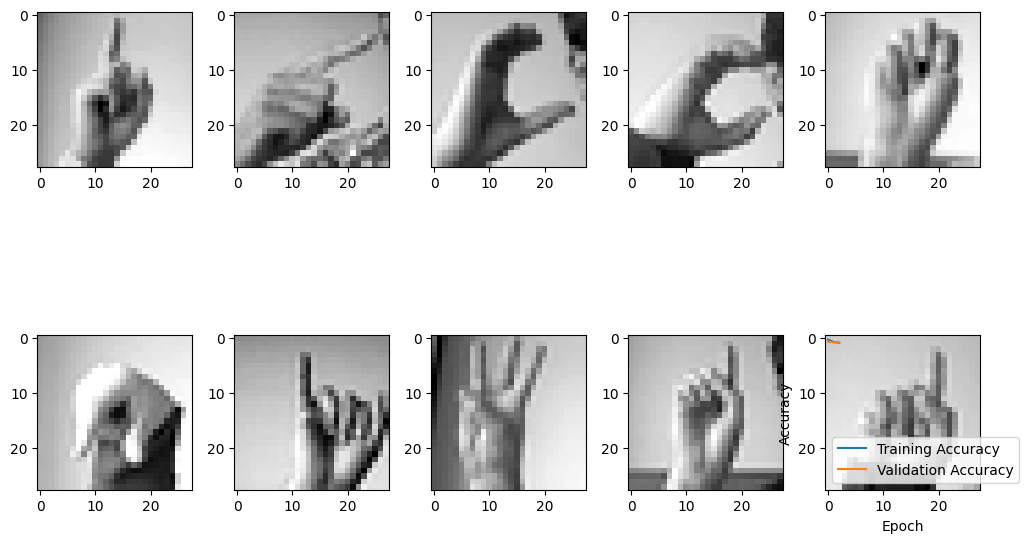

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
import cv2
import matplotlib.pyplot as plt
train_data = pd.read_csv('/content/sign_mnist_train.csv')
test_data = pd.read_csv('/content/sign_mnist_test.csv')

train_labels = train_data['label']
train_images = train_data.drop('label', axis=1)

test_labels = test_data['label']
test_images = test_data.drop('label', axis=1)

train_images = np.array(train_images).reshape(-1, 28, 28, 1).astype('float32') / 255.0
test_images = np.array(test_images).reshape(-1, 28, 28, 1).astype('float32') / 255.0

lb = LabelBinarizer()
train_labels = lb.fit_transform(train_labels)
test_labels = lb.transform(test_labels)

num_classes = 26
if train_labels.shape[1] < num_classes:
    missing_classes = num_classes - train_labels.shape[1]
    train_labels = np.pad(train_labels, ((0, 0), (0, missing_classes)), 'constant')

if test_labels.shape[1] < num_classes:
    missing_classes = num_classes - test_labels.shape[1]
    test_labels = np.pad(test_labels, ((0, 0), (0, missing_classes)), 'constant')

model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(26, activation='softmax'))

f, ax = plt.subplots(2,5)
f.set_size_inches(10, 10)
k = 0
for i in range(2):
    for j in range(5):
        ax[i,j].imshow(train_images[k].reshape(28, 28) , cmap = "gray")
        k += 1
    plt.tight_layout()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=3, batch_size=64, validation_data=(test_images, test_labels))
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_acc:.2f}')

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
